In [231]:
import sympy as sp
from scipy.integrate import odeint, solve_ivp
import numpy as np
import matplotlib.pyplot as plt
#from numba import jit


In [325]:
# On introduit des constantes
M = 7
m = .1 * M
R = 0.20
J = 0.4 * M * (R**2)
l = 0.1 * R
coef_frottement_dynamique = 1.5
coef_frottement_statique = 0.5
g = 9.81

# Définir les variables et fonctions symboliques
t = sp.symbols('t')

In [327]:
# On définit les angles d'euler
theta = sp.Function('theta')(t)
psi = sp.Function('psi')(t)
phi = sp.Function('phi')(t)
angle = sp.Matrix([theta, psi, phi])

# On définit les coordonées de B
x = sp.Function('x')(t)
y = sp.Function('y')(t)
x_point = sp.diff(x, t)
y_point = sp.diff(y, t)
x_pointpoint = sp.diff(x_point ,t)
y_pointpoint = sp.diff(y_point ,t)
pos_B = sp.Matrix([x, y, R])
vB = sp.diff(pos_B)
aB = sp.diff(vB)

# On définit le vecteur BA


# Définir les dérivées par rapport à t
theta_point = sp.diff(theta, t)
psi_point = sp.diff(psi, t)
phi_point = sp.diff(phi, t)
theta_pointpoint = sp.diff(theta_point, t)
psi_pointpoint = sp.diff(psi_point, t)
phi_pointpoint = sp.diff(phi_point, t)

# Construire Oméga
wx = theta_point * sp.cos(t).subs(t, psi) + phi_point * \
    sp.sin(t).subs(t, theta) * sp.sin(t).subs(t, psi)
wy = theta_point * sp.sin(t).subs(t, psi) - phi_point * \
    sp.sin(t).subs(t, theta) * sp.cos(t).subs(t, psi)
wz = psi_point + phi_point * sp.cos(t).subs(t, theta)
Omega = sp.Matrix([wx, wy, wz])
Omega_point = sp.diff(Omega)

In [329]:
# calcul de l'accélération de A                  BA=l*z(theta)
xa = x + l * sp.sin(t).subs(t, theta) * sp.sin(t).subs(t, psi)
ya = y - l * sp.sin(t).subs(t, theta) * sp.cos(t).subs(t, psi)
za = R + l * sp.cos(t).subs(t, theta)
pos_A = sp.Matrix([xa, ya, za])
pos_BA = sp.Matrix([xa - x, ya - y, za - R])
# v(A/R) = v(B/R) + v(A/R') + Oméga^BA
vAx_Rb = l * theta_point * (sp.cos(t).subs(t, theta) * sp.sin(t).subs(t, phi))
vAy_Rb = -l * theta_point * (sp.cos(t).subs(t, theta) * sp.cos(t).subs(t, phi))
vAz_Rb = -l * theta_point * sp.sin(t).subs(t, theta)
vA_Rb = sp.Matrix([vAx_Rb, vAy_Rb, vAz_Rb])
vA = vB + vA_Rb + Omega.cross(pos_BA)
# a(A/R)= a(B/R)+a(A/R')+ 2 Omega ^ v(A/R') + Omega_point ^ BA + Omega^(Omega^BA)
aAx_Rb = l * theta_pointpoint * sp.cos(t).subs(t, theta) * sp.sin(t).subs(
    t, psi) - l * theta_point ** 2 * sp.sin(t).subs(t, theta) * sp.sin(t).subs(t, psi)
aAy_Rb = - l * theta_pointpoint * (sp.cos(t).subs(t, theta) * sp.cos(t).subs(
    t, phi)) + l * theta_point ** 2 * sp.sin(t).subs(t, theta) * sp.cos(t).subs(t, psi)
aAz_Rb = - l * theta_pointpoint * \
    sp.sin(t).subs(t, theta) - l * theta_point ** 2 * sp.cos(t).subs(t, theta)
aA_Rb = sp.Matrix([aAx_Rb, aAy_Rb, aAz_Rb])
aA = aB + aA_Rb + 2 * \
    Omega.cross(vA_Rb) + Omega_point.cross(pos_BA) + \
    Omega.cross(Omega.cross(pos_BA))

# calcul de l'accélération de G
xG = x + (m / (m + M)) * l * sp.sin(t).subs(t, theta) * sp.sin(t).subs(t, psi)
yG = y - (m / (m + M)) * l * sp.sin(t).subs(t, theta) * sp.cos(t).subs(t, psi)
zG = R + (m / (m + M)) * l * sp.cos(t).subs(t, theta)
pos_G = sp.Matrix([xG, yG, zG])
pos_BG = sp.Matrix([xG - x, yG - y, zG - R])
# v(G/R) = v(B/R) + v(G/R') + Oméga^BG
vGx_Rb = (m / (m + M)) * l * theta_point * \
    (sp.cos(t).subs(t, theta) * sp.sin(t).subs(t, phi))
vGy_Rb = -(m / (m + M)) * l * theta_point * \
    (sp.cos(t).subs(t, theta) * sp.cos(t).subs(t, phi))
vGz_Rb = -(m / (m + M)) * l * theta_point * sp.sin(t).subs(t, theta)
vG_Rb = sp.Matrix([vGx_Rb, vGy_Rb, vGz_Rb])
vG = vB + vG_Rb + Omega.cross(pos_BG)
# a(A/R)= a(B/R)+a(A/R')+ 2 Omega ^ v(A/R') + Omega_point ^ BA + Omega^(Omega^BA)
aGx_Rb = (m / (m + M)) * l * theta_pointpoint * sp.cos(t).subs(t, theta) * sp.sin(t).subs(t, psi) - \
    (m / (m + M)) * l * theta_point ** 2 * \
    sp.sin(t).subs(t, theta) * sp.sin(t).subs(t, psi)
aGy_Rb = - (m / (m + M)) * l * theta_pointpoint * (sp.cos(t).subs(t, theta) * sp.cos(t).subs(t, phi)
                                                   ) + (m / (m + M)) * l * theta_point ** 2 * sp.sin(t).subs(t, theta) * sp.cos(t).subs(t, psi)
aGz_Rb = - (m / (m + M)) * l * theta_pointpoint * sp.sin(t).subs(t, theta) - \
    (m / (m + M)) * l * theta_point ** 2 * sp.cos(t).subs(t, theta)
aG_Rb = sp.Matrix([aGx_Rb, aGy_Rb, aGz_Rb])
aG = aB + aG_Rb + 2 * \
    Omega.cross(vG_Rb) + Omega_point.cross(pos_BG) + \
    Omega.cross(Omega.cross(pos_BG))

In [331]:
# Écriture de Vg
Vg = vB + Omega.cross(sp.Matrix([0, 0, -R]))
Vg_point = sp.diff(Vg, t)
norme_Vg = Vg.norm()
# Écriture des
# Bilan des forces:
P_B = sp.Matrix([0, 0, -M * g])
P_A = sp.Matrix([0, 0, -m * g])
N = sp.Matrix([0, 0, aA[2]]) - P_A - P_B
# On définit T
T = -coef_frottement_dynamique * N.norm() / norme_Vg * Vg
T_Vg = M * aB + m * aA



In [333]:
# TRC
TRC = sp.Eq(M * aB + m * aA, P_B + P_A + N + T)
TRC1 = sp.Eq(M * aB[0] + m * aA[0], P_B[0] + P_A[0] + N[0] + T[0])
TRC2 = sp.Eq(M * aB[1] + m * aA[1], P_B[1] + P_A[1] + N[1] + T[1])
TRC3 = sp.Eq(M * aB[2] + m * aA[2], P_B[2] + P_A[2] + N[2] + T[2])

# Bilan des Moments en B
MP_A = pos_BA.cross(P_A)
MT = sp.Matrix([0, 0, -R]).cross(T)
MT_Vg = sp.Matrix([0, 0, -R]).cross(T_Vg)
sp.pprint(MP_A)
# TMC
# Calcul de L_B
L_B = J * Omega + pos_BG.cross((m+M)*vG)
L_B_point = J * Omega_point - vB.cross((m+M)*vG) + pos_BG.cross(aG)

TMC = sp.Eq(L_B_point, MP_A + MT)
TMC1 = sp.Eq(L_B_point[0], MP_A[0] + MT[0])
TMC2 = sp.Eq(L_B_point[1], MP_A[1] + MT[1])
TMC3 = sp.Eq(L_B_point[2], MP_A[2] + MT[2])
TMC_Vg1 = sp.Eq(L_B_point[0], MP_A[0] + MT_Vg[0])
sp.pprint(L_B_point[0])
TMC_Vg2 = sp.Eq(L_B_point[1], MP_A[1] + MT_Vg[1])
TMC_Vg3 = sp.Eq(L_B_point[2], MP_A[2] + MT_Vg[2])


⎡0.13734⋅sin(θ(t))⋅cos(ψ(t))⎤
⎢                           ⎥
⎢0.13734⋅sin(ψ(t))⋅sin(θ(t))⎥
⎢                           ⎥
⎣             0             ⎦
                                                                              
  ⎛        ⎛          d                              d       ⎞                
- ⎜- 0.014⋅⎜sin(ψ(t))⋅──(θ(t)) - sin(θ(t))⋅cos(ψ(t))⋅──(φ(t))⎟⋅sin(ψ(t))⋅sin(θ
  ⎝        ⎝          dt                             dt      ⎠                
                                                                              

                                                                              
             ⎛                    d                    d       ⎞              
(t)) - 0.014⋅⎜sin(ψ(t))⋅sin(θ(t))⋅──(φ(t)) + cos(ψ(t))⋅──(θ(t))⎟⋅sin(θ(t))⋅cos
             ⎝                    dt                   dt      ⎠              
                                                                              

                                                          

In [335]:
# On crée une matrice pour inverser le système
equations=[TRC1, TRC2, TMC1, TMC2, TMC3]
equations_Vg=[sp.Eq(Vg_point[0],0),sp.Eq(Vg_point[1],0),TMC_Vg1,TMC_Vg2,TMC_Vg3]
#equations_Vg=[sp.Eq(Vg[0],0), sp.Eq(Vg[1],0), TMC3]          #On à d'autres systèmes d'eq si Vg=0
variables=[x_pointpoint, y_pointpoint, theta_pointpoint, psi_pointpoint, phi_pointpoint]
variables_Vg=[theta_pointpoint, psi_pointpoint, phi_pointpoint]
def generate_matrix(equations, variables):
    # Initialiser les matrices des coefficients et des termes constants
    A = sp.zeros(len(equations), len(variables))
    B = sp.zeros(len(equations), 1)
    
    # Parcourir chaque équation
    for i, eq in enumerate(equations):
        # Mettre l'équation sous forme de a1*x1 + a2*x2 + ... = b
        eq = eq.expand().rewrite(sp.Add)
        
        # Parcourir chaque variable
        for j, var in enumerate(variables):
            # Extraire le coefficient de la variable
            coeff = eq.coeff(var)
            A[i, j] = coeff
            
        # Extraire le terme constant (termes sans variables)
        B[i] = -eq.subs({var: 0 for var in variables})
    
    return A, B

In [341]:
A, B = generate_matrix(equations, variables)
#A_Vg, B_Vg = generate_matrix(equations_Vg, variables_Vg) #Matrice des eq si Vg=0
#det_A=A.det()
#det_A_Vg=A_Vg.det()
#singular_condition = sp.Eq(det_A, 0)
#singular_condition_Vg = sp.Eq(det_A_Vg, 0)
A_inv= A.inv() 
#A_Vg_inv = A_Vg.inv() #if not singular_condition else eye(5)

In [343]:
A_Vg, B_Vg = generate_matrix(equations_Vg, variables) #Matrice des eq si Vg=0
#det_A_Vg=A_Vg.det()





In [345]:
eq1= sp.Eq((A_inv*B)[0],0)   
eq2= sp.Eq((A_inv*B)[1],0)    
eq3= sp.Eq((A_inv*B)[2],0)  
eq4= sp.Eq((A_inv*B)[3],0)  
eq5= sp.Eq((A_inv*B)[4],0)

#eq1_Vg = sp.Eq((A_Vg_inv*B_Vg)[0],0)           #eq si Vg=0
#eq2_Vg = sp.Eq((A_Vg_inv*B_Vg)[1],0)    
#eq3_Vg = sp.Eq((A_Vg_inv*B_Vg)[2],0)  


# Convertir les équations symboliques en fonctions lambda

f_eq1 = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), eq1.lhs - eq1.rhs)
f_eq2 = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), eq2.lhs - eq2.rhs)
f_eq3 = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), eq3.lhs - eq3.rhs)
f_eq4 = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), eq4.lhs - eq4.rhs)
f_eq5 = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), eq5.lhs - eq5.rhs)
f_norme_Vg = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), norme_Vg)

f_B = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), B)
f_A = sp.lambdify((theta, psi, phi, theta_point, psi_point, phi_point, x, y, x_point, y_point), A)
f_A_inv = sp.lambdify((theta, psi, phi, theta_point, psi_point, phi_point, x, y, x_point, y_point), A_inv)

f_B_Vg = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), B_Vg)
f_A_Vg = sp.lambdify((theta, psi, phi, theta_point, psi_point, phi_point, x, y, x_point, y_point), A_Vg)

#f_eq1_Vg = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), eq1_Vg.lhs - eq1_Vg.rhs)
#f_eq2_Vg = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), eq2_Vg.lhs - eq2_Vg.rhs)
#f_eq3_Vg = sp.lambdify((x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point), eq3_Vg.lhs - eq3_Vg.rhs)

[[ 1.          0.         -0.          0.          0.        ]
 [ 0.          1.          0.2         0.          0.        ]
 [ 0.         -1.54181818  0.11480331 -0.          0.        ]
 [ 1.54181818  0.          0.          0.         -0.        ]
 [ 0.          0.          0.          0.112       0.112     ]]
[ 1. nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan]


<lambdifygenerated-73>:2: RuntimeWarning: invalid value encountered in scalar divide
  return array([[-1.5*_Dummy_9472281*abs(0.02*_Dummy_9472282**2*sin(_Dummy_9472288)**2*cos(_Dummy_9472287) + 0.04*_Dummy_9472282**2*sin(_Dummy_9472288)*sin(_Dummy_9472289)*cos(_Dummy_9472287) + 0.02*_Dummy_9472282**2*cos(_Dummy_9472287)*cos(_Dummy_9472288)**2 + 0.04*_Dummy_9472282**2*cos(_Dummy_9472287)*cos(_Dummy_9472288)*cos(_Dummy_9472289) + 0.02*_Dummy_9472282**2*cos(_Dummy_9472287) + 0.04*_Dummy_9472282*_Dummy_9472284*sin(_Dummy_9472287)*sin(_Dummy_9472288)*cos(_Dummy_9472287)*cos(_Dummy_9472289) - 0.04*_Dummy_9472282*_Dummy_9472284*sin(_Dummy_9472287)*sin(_Dummy_9472289)*cos(_Dummy_9472287)*cos(_Dummy_9472288) - 75.537)/sqrt(abs(_Dummy_9472280 + 0.2*_Dummy_9472282*cos(_Dummy_9472288) + 0.2*_Dummy_9472284*sin(_Dummy_9472287)*sin(_Dummy_9472288))**2 + abs(_Dummy_9472281 - 0.2*_Dummy_9472282*sin(_Dummy_9472288) + 0.2*_Dummy_9472284*sin(_Dummy_9472287)*cos(_Dummy_9472288))**2) + 0.014*_Dummy_9472282*

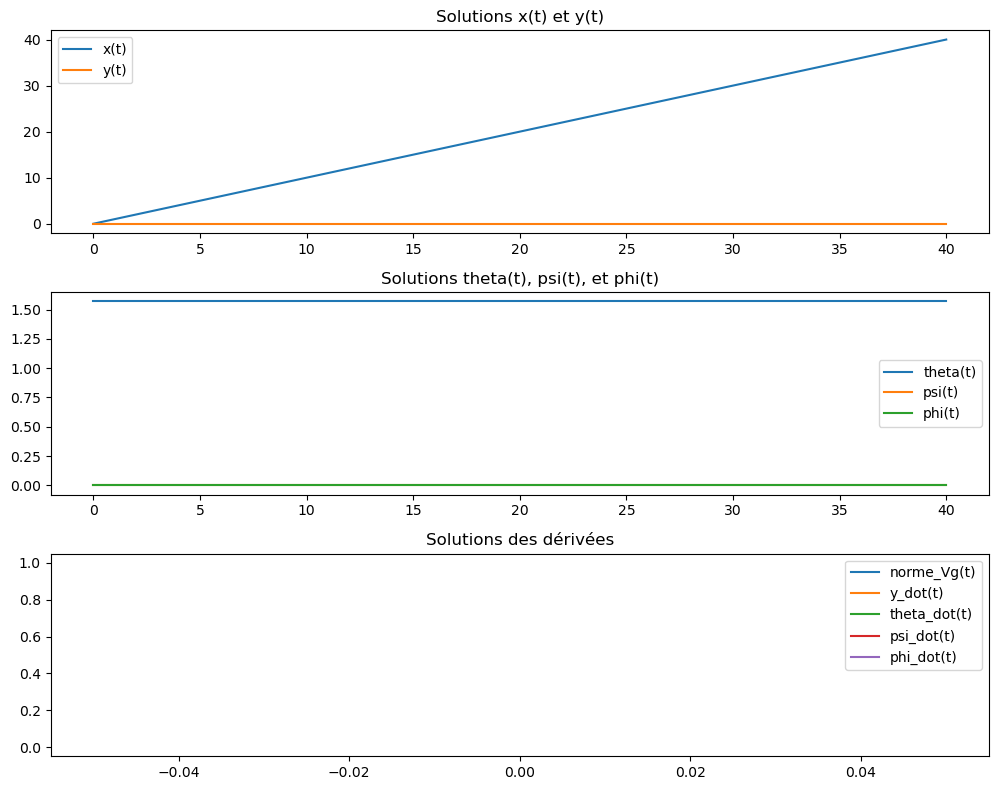

In [347]:
# On utilise la méthode d'Euler pour résoudre les Eq
CI = [0, 0, np.pi/2, 0, 0, 1, 0, 0, 0, 0]
print(f_A_Vg(0,0,np.pi/2,0,0,1,0,0,0,0))
# Time span
t_span = 4000
num_steps = 100
dt = t_span / num_steps
t_eval = np.linspace(0, t_span, num_steps + 1)

# Arrays to store the solution
solution = np.zeros((len(CI), len(t_eval)))
solution[:, 0] = CI

# Euler method
for i in range(num_steps):
    x, y, theta, psi, phi, x_dot, y_dot, theta_dot, psi_dot, phi_dot = solution[:, i]
    norme_Vg_value = f_norme_Vg(x, y, theta, psi, phi, x_dot, y_dot, theta_dot, psi_dot, phi_dot)
    
    if norme_Vg_value > 10**(-2):
        A_num = np.array(f_A_Vg(theta, psi, phi, theta_dot, psi_dot, phi_dot, x, y, x_dot, y_dot)).astype(np.float64)
        B_num = np.array(f_B(theta, psi, phi, theta_dot, psi_dot, phi_dot, x, y, x_dot, y_dot)).astype(np.float64)
        
    else:
        A_num = np.array(f_A_Vg(theta, psi, phi, theta_dot, psi_dot, phi_dot, x, y, x_dot, y_dot)).astype(np.float64)
        B_num = np.array(f_B_Vg(theta, psi, phi, theta_dot, psi_dot, phi_dot, x, y, x_dot, y_dot)).astype(np.float64)
    
    if np.linalg.det(A_num) != 0:
        coeff_matrix_inv = np.linalg.inv(A_num)
    else:
        coeff_matrix_inv = np.linalg.pinv(A_num)
    
    prdt = np.dot(coeff_matrix_inv, B_num)
    dx_ddot, dy_ddot, dtheta_ddot, dpsi_ddot, dphi_ddot = prdt.flatten()
    
    # Update variables using Euler method
    solution[0, i+1] = x + x_dot * dt
    solution[1, i+1] = y + y_dot * dt
    solution[2, i+1] = theta + theta_dot * dt
    solution[3, i+1] = psi + psi_dot * dt
    solution[4, i+1] = phi + phi_dot * dt
    solution[5, i+1] = x_dot + dx_ddot * dt
    solution[6, i+1] = y_dot + dy_ddot * dt
    solution[7, i+1] = theta_dot + dtheta_ddot * dt
    solution[8, i+1] = psi_dot + dpsi_ddot * dt
    solution[9, i+1] = phi_dot + dphi_ddot * dt
    # Extract solutions
x_sol = solution[0]
y_sol = solution[1]
theta_sol = solution[2]
psi_sol = solution[3]
phi_sol = solution[4]
x_dot_sol = solution[5]
y_dot_sol = solution[6]
theta_dot_sol = solution[7]
psi_dot_sol = solution[8]
phi_dot_sol = solution[9]

# Plot results
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(t_eval, x_sol, label='x(t)')
plt.plot(t_eval, y_sol, label='y(t)')
plt.legend()
plt.title('Solutions x(t) et y(t)')

plt.subplot(3, 1, 2)
plt.plot(t_eval, theta_sol, label='theta(t)')
plt.plot(t_eval, psi_sol, label='psi(t)')
plt.plot(t_eval, phi_sol, label='phi(t)')
plt.legend()
plt.title('Solutions theta(t), psi(t), et phi(t)')
print(x_dot_sol)
plt.subplot(3, 1, 3)
plt.plot(t_eval, f_norme_Vg(x_sol, y_sol, theta_sol, psi_sol, phi_sol, x_dot_sol, y_dot_sol, theta_dot_sol, psi_dot_sol, phi_dot_sol), label='norme_Vg(t)')
plt.plot(t_eval, y_dot_sol, label='y_dot(t)')
plt.plot(t_eval, theta_dot_sol, label='theta_dot(t)')
plt.plot(t_eval, psi_dot_sol, label='psi_dot(t)')
plt.plot(t_eval, phi_dot_sol, label='phi_dot(t)')
plt.legend()
plt.title('Solutions des dérivées')

plt.tight_layout()
plt.show()


In [227]:
def system(t, variables):
    x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point = variables
    dxdt = x_point
    dydt = y_point
    dthetadt = theta_point
    dpsidt = psi_point
    dphidt = phi_point
    norme_Vg_value = f_norme_Vg(x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point)
    if norme_Vg_value > 10**(-2):
        dxdt = x_point
        dydt = y_point
        dx_dotdt = f_eq1(x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point)
        dy_dotdt = f_eq2(x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point)
        dtheta_dotdt = f_eq3(x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point)
        dpsi_dotdt = f_eq4(x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point)
        dphi_dotdt = f_eq5(x, y, theta, psi, phi, x_point, y_point, theta_point, psi_point, phi_point)
        return np.ravel([dxdt, dydt, dthetadt, dpsidt, dphidt, dx_dotdt, dy_dotdt, dtheta_dotdt, dpsi_dotdt, dphi_dotdt])
    else :
        # Substituer les valeurs numériques dans la matrice symbolique
    
        coeff_matrix_num = f_A_Vg(theta, psi, phi, theta_point, psi_point, phi_point, x, y, x_point, y_point)
        coeff_matrix_num = np.array(coeff_matrix_num).astype(np.float64)
    
        # Vérifier si la matrice est inversible
        if np.linalg.det(coeff_matrix_num) != 0:
            # Calculer l'inverse numérique de la matrice
            coeff_matrix_inv = np.linalg.inv(coeff_matrix_num)
        else:
            # Utiliser une méthode alternative si la matrice est singulière
            coeff_matrix_inv = np.linalg.pinv(coeff_matrix_num,rcond=1e-15)  # Pseudo-inverse de Moore-Penrose
        b_num = f_B_Vg(theta, psi, phi, theta_point, psi_point, phi_point, x, y, x_point, y_point)
        b_num = np.array(b_num).astype(np.float64)
        prdt = np.dot(coeff_matrix_inv, b_num)
        dx_dotdt, dy_dotdt, dtheta_dotdt, dpsi_dotdt, dphi_dotdt = prdt.flatten()
        return np.ravel([dxdt, dydt, dthetadt, dpsidt, dphidt, dx_dotdt, dy_dotdt, dtheta_dotdt, dpsi_dotdt, dphi_dotdt])

# Conditions initiales
CI = [0, 0, sp.pi/2, 0, 0, 1, 0, 0, 5, 0]

# Intervalle de temps
t = np.linspace(0, .15, 200)

# Résoudre les équations différentielles
#solution = odeint(system, CI, t)

# Temps de simulation
t_span = (0, 1)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
solution = solve_ivp(system, t_span, CI, t_eval=t_eval, method='RK23', rtol=1e-5, atol=1e-8)
# Résolution du système d'équations différentielles
#solution = solve_ivp(system, t_span, CI, t_eval=t_eval, method='RK45', rtol=1e-5, atol=1e-8)

# Extraire les résultats
x_sol = solution.y[0]
y_sol = solution.y[1]
theta_sol = solution.y[2]
psi_sol = solution.y[3]
phi_sol = solution.y[4]

# Tracer les résultats
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(t, x_sol, label='x(t)')
plt.plot(t, y_sol, label='y(t)')
plt.legend()
plt.title('Solutions x(t) et y(t)')

plt.subplot(3, 1, 2)
plt.plot(t, theta_sol, label='theta(t)')
plt.plot(t, psi_sol, label='psi(t)')
plt.plot(t, phi_sol, label='phi(t)')
plt.legend()
plt.title('Solutions theta(t), psi(t), et phi(t)')

plt.subplot(3, 1, 3)
plt.plot(t, f_norme_Vg(solution.y[0], solution.y[1], solution.y[2], solution.y[3], solution.y[4], solution.y[5], solution.y[6], solution.y[7], solution.y[8], solution.y[9]), label='norme_Vg(t)')

#plt.plot(t, solution.y[5], label='x_dot(t)')
#plt.plot(t, solution.y[6], label='y_dot(t)')
#plt.plot(t, solution.y[7], label='theta_dot(t)')
#plt.plot(t, solution.y[8], label='psi_dot(t)')
#plt.plot(t, solution.y[9], label='phi_dot(t)')
#plt.legend()
plt.title('Solutions des dérivées')

plt.tight_layout()
plt.show()


KeyboardInterrupt

